# EDA del dataset `soporte.csv`

## Caso practico: Union Central Voz


## Hipotesis iniciales

H1: A mayor stress_calidad_lag, menor será la satisfacción del cliente.
H2: A mayor stress_calidad_lag, menor será la satisfacción del cliente.
H3: El canal de atención influye en la duración de la interacción
H4: interacciones más largas (duracion_min) están asociadas a menor satisfacción.

In [53]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)

In [54]:
def missing_summary(df: pd.DataFrame) -> pd.DataFrame:
    summary = pd.DataFrame({
        'n_missing': df.isna().sum(),
        'pct_missing': df.isna().mean() * 100,
        'dtype': df.dtypes.astype(str)
    })
    return summary.sort_values(['n_missing', 'pct_missing'], ascending=False)


def iqr_outlier_mask(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors='coerce').dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (pd.to_numeric(series, errors='coerce') < lower) | (pd.to_numeric(series, errors='coerce') > upper)


def cramers_v(x: pd.Series, y: pd.Series) -> float:
    table = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(table)[0]
    n = table.values.sum()
    r, k = table.shape
    return np.sqrt((chi2 / n) / max(min(k - 1, r - 1), 1))

## 1. Carga de datos

In [17]:
path_soporte = '/Users/saraelbachouti/Desktop/UCV-Churn/data/raw/interacciones_soporte.csv'
df = pd.read_csv(path_soporte)

print(f'Filas: {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
df.head()


Filas: 308,487
Columnas: 13


,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes
0,I923052492930,C000001,2023-02-07,2023-02-01,telefono,Facturación,9.50,0,4.00,0.41,0,0,0
1,I692361171059,C000001,2023-04-20,2023-04-01,app_chat,Facturación,3.90,1,4.00,0.43,0,0,0
2,I354109146175,C000001,2023-04-27,2023-04-01,app_chat,Baja / portabilidad,2.80,1,5.00,0.43,0,0,0
3,I986032353420,C000001,2023-05-04,2023-05-01,telefono,Consulta general,8.40,1,3.00,0.45,0,0,0
4,I553023863181,C000001,2023-06-26,2023-06-01,telefono,Impago / pago,4.50,1,4.00,0.39,0,0,0


## 2. Estructura, tipos y primera lectura

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 308487 entries, 0 to 308486
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   interaccion_id         308487 non-null  str    
 1   cliente_id             308487 non-null  str    
 2   fecha_evento           308487 non-null  str    
 3   mes                    308487 non-null  str    
 4   canal                  308487 non-null  str    
 5   motivo                 303847 non-null  str    
 6   duracion_min           308487 non-null  float64
 7   resuelto               308487 non-null  int64  
 8   satisfaccion_post      303858 non-null  float64
 9   stress_calidad_lag     308487 non-null  float64
 10  incidencia_masiva_lag  308487 non-null  int64  
 11  impago_mes             308487 non-null  int64  
 12  dias_retraso_mes       308487 non-null  int64  
dtypes: float64(3), int64(4), str(6)
memory usage: 30.6 MB


In [19]:
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
interaccion_id,308487,303929,I716491295118,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cliente_id,308487,9973,C005384,84,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha_evento,308487,1998,2023-02-14,460,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mes,308487,36,2023-02-01,11686,NaN,NaN,NaN,NaN,NaN,NaN,NaN
canal,308487,7,telefono,137187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
motivo,303847,7,Calidad de señal,62963,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duracion_min,"308,487.00",NaN,NaN,NaN,6.02,3.94,-20.60,3.20,5.90,8.60,24.10
resuelto,"308,487.00",NaN,NaN,NaN,0.58,0.49,0.00,0.00,1.00,1.00,1.00
satisfaccion_post,"303,858.00",NaN,NaN,NaN,3.44,1.00,1.00,3.00,3.00,4.00,5.00
stress_calidad_lag,"308,487.00",NaN,NaN,NaN,0.45,0.16,0.00,0.35,0.44,0.54,0.80


## 3. Diagnostico de calidad de datos

In [20]:
missing = missing_summary(df)
display(missing)


,n_missing,pct_missing,dtype
motivo,4640,1.50,str
satisfaccion_post,4629,1.50,float64
interaccion_id,0,0.00,str
cliente_id,0,0.00,str
fecha_evento,0,0.00,str
mes,0,0.00,str
canal,0,0.00,str
duracion_min,0,0.00,float64
resuelto,0,0.00,int64
stress_calidad_lag,0,0.00,float64


In [28]:
df.duplicated().sum()

np.int64(4558)

In [29]:
df['interaccion_id'].duplicated().sum()

np.int64(4558)

In [30]:
expected_resuelto = {0, 1}
expected_incidencia_masiva = {0, 1}
expected_impago = {0, 1}

satisfaccion = pd.to_numeric(df['satisfaccion_post'], errors='coerce')
stress = pd.to_numeric(df['stress_calidad_lag'], errors='coerce')

quality_checks = {
    'soporte_duplicados_exactos': int(df.duplicated().sum()),
    'interaccion_id_duplicado': int(df['interaccion_id'].duplicated().sum()),

    'resuelto_fuera_catalogo': int((~df['resuelto'].isin(expected_resuelto)).sum()),
    'incidencia_masiva_lag_fuera_catalogo': int((~df['incidencia_masiva_lag'].isin(expected_incidencia_masiva)).sum()),
    'impago_mes_fuera_catalogo': int((~df['impago_mes'].isin(expected_impago)).sum()),

    'duracion_min_negativa': int((pd.to_numeric(df['duracion_min'], errors='coerce') < 0).sum()),
    'dias_retraso_mes_negativo': int((pd.to_numeric(df['dias_retraso_mes'], errors='coerce') < 0).sum()),

    'satisfaccion_post_fuera_rango': int((satisfaccion.notna() & ~satisfaccion.between(0, 10)).sum()),
    'stress_calidad_lag_fuera_rango': int((stress.notna() & ~stress.between(0, 1)).sum())
}

pd.DataFrame.from_dict(quality_checks, orient='index', columns=['n_casos'])

,n_casos
soporte_duplicados_exactos,4558
interaccion_id_duplicado,4558
resuelto_fuera_catalogo,0
incidencia_masiva_lag_fuera_catalogo,0
impago_mes_fuera_catalogo,0
duracion_min_negativa,4635
dias_retraso_mes_negativo,0
satisfaccion_post_fuera_rango,0
stress_calidad_lag_fuera_rango,0


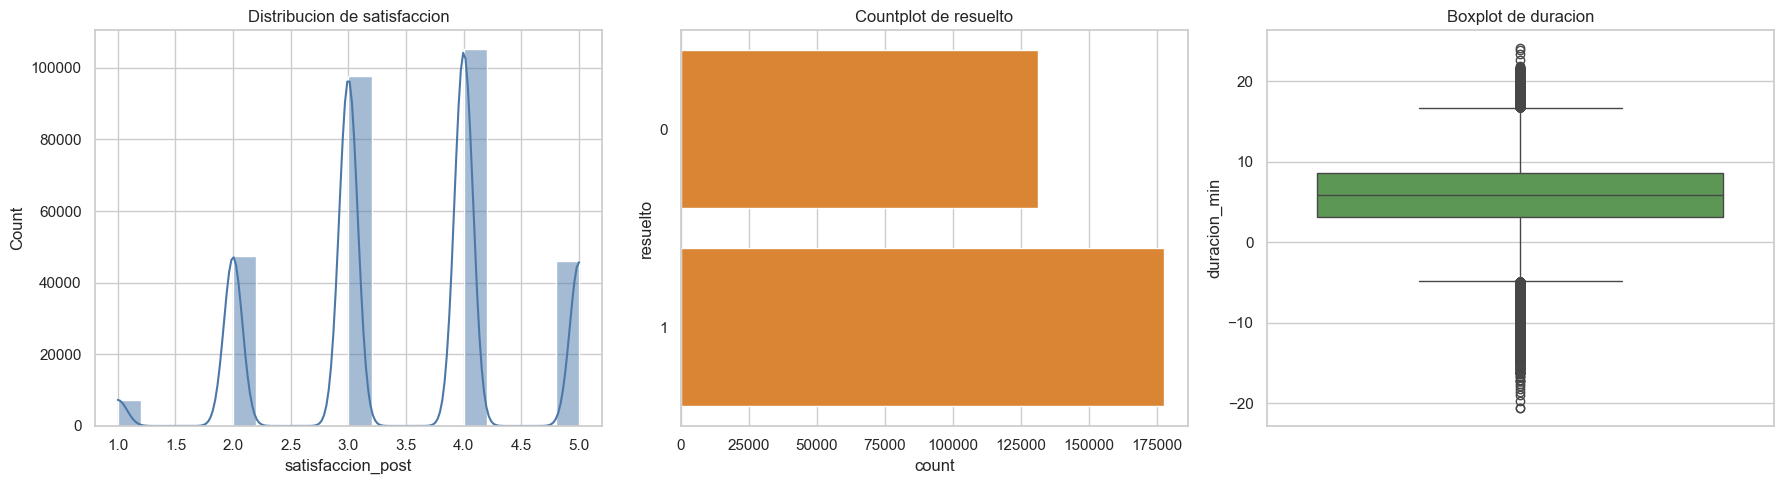

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['satisfaccion_post'], bins=20, kde=True, ax=axes[0], color='#4C78A8')
axes[0].set_title('Distribucion de satisfaccion')

sns.countplot(y=df['resuelto'], ax=axes[1], color='#F58518')
axes[1].set_title('Countplot de resuelto')

sns.boxplot(y=df['duracion_min'], ax=axes[2], color='#54A24B')
axes[2].set_title('Boxplot de duracion')

plt.tight_layout()

## 4. Construccion de una base analitica minima

In [36]:
df_analitica = df.copy()

In [40]:
df_analitica = df_analitica.rename(columns={'fecha evento': 'fecha_evento'})

df_analitica['fecha_evento'] = pd.to_datetime(df_analitica['fecha_evento'], errors='coerce')

df_analitica['mes'] = df_analitica['fecha_evento'].dt.to_period('M')
df_analitica['dia_semana'] = df_analitica['fecha_evento'].dt.day_name()
df_analitica['hora'] = df_analitica['fecha_evento'].dt.hour

## 5. Analisis univariante

In [41]:
num_cols = df_analitica.select_dtypes(include=np.number).columns
cat_cols = df_analitica.select_dtypes(include='object').columns

duracion_min


count   308,487.00
mean          6.02
std           3.94
min         -20.60
25%           3.20
50%           5.90
75%           8.60
max          24.10
Name: duracion_min, dtype: float64

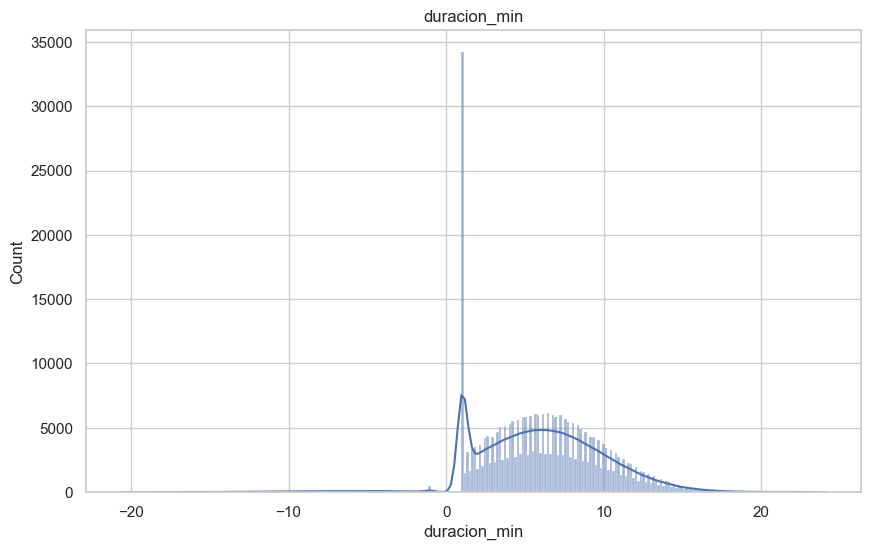

resuelto


count   308,487.00
mean          0.58
std           0.49
min           0.00
25%           0.00
50%           1.00
75%           1.00
max           1.00
Name: resuelto, dtype: float64

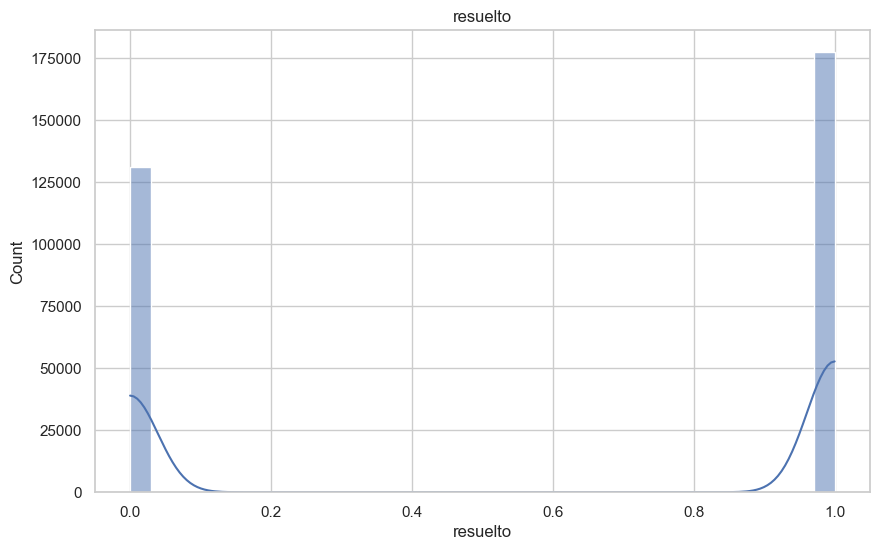

satisfaccion_post


count   303,858.00
mean          3.44
std           1.00
min           1.00
25%           3.00
50%           3.00
75%           4.00
max           5.00
Name: satisfaccion_post, dtype: float64

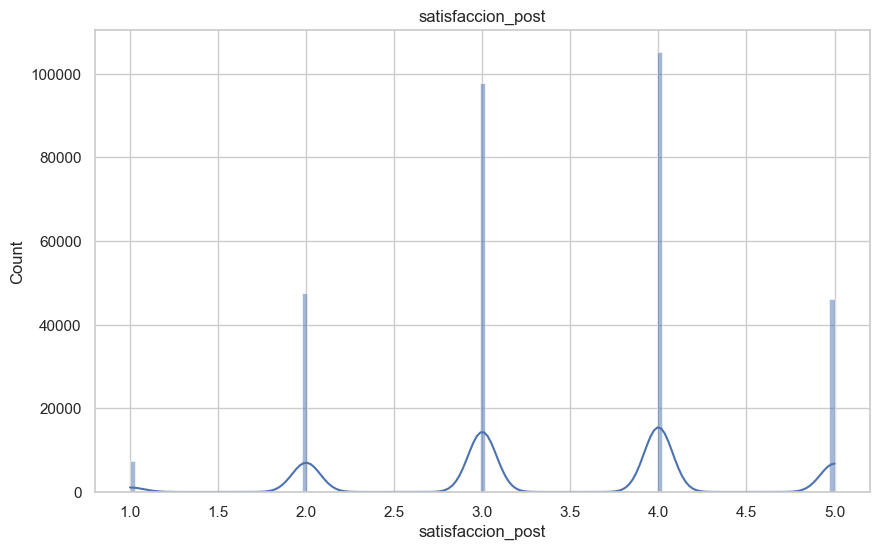

stress_calidad_lag


count   308,487.00
mean          0.45
std           0.16
min           0.00
25%           0.35
50%           0.44
75%           0.54
max           0.80
Name: stress_calidad_lag, dtype: float64

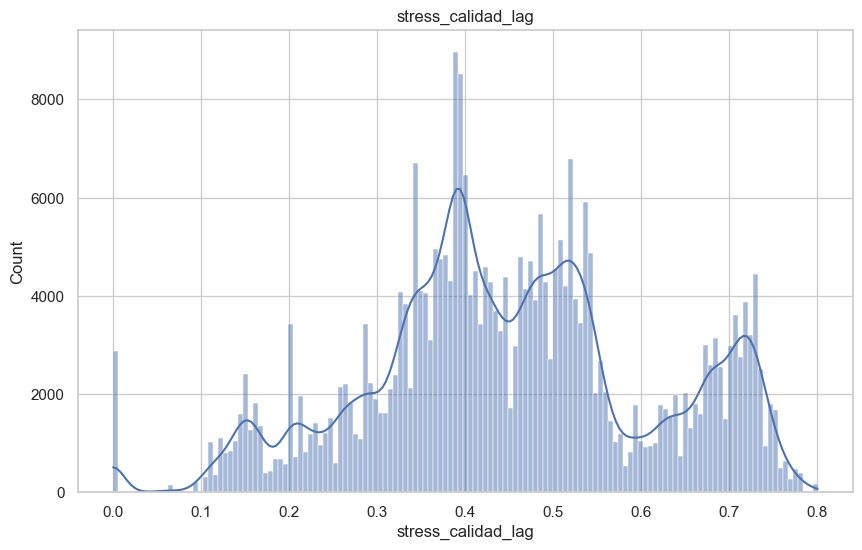

incidencia_masiva_lag


count   308,487.00
mean          0.01
std           0.08
min           0.00
25%           0.00
50%           0.00
75%           0.00
max           1.00
Name: incidencia_masiva_lag, dtype: float64

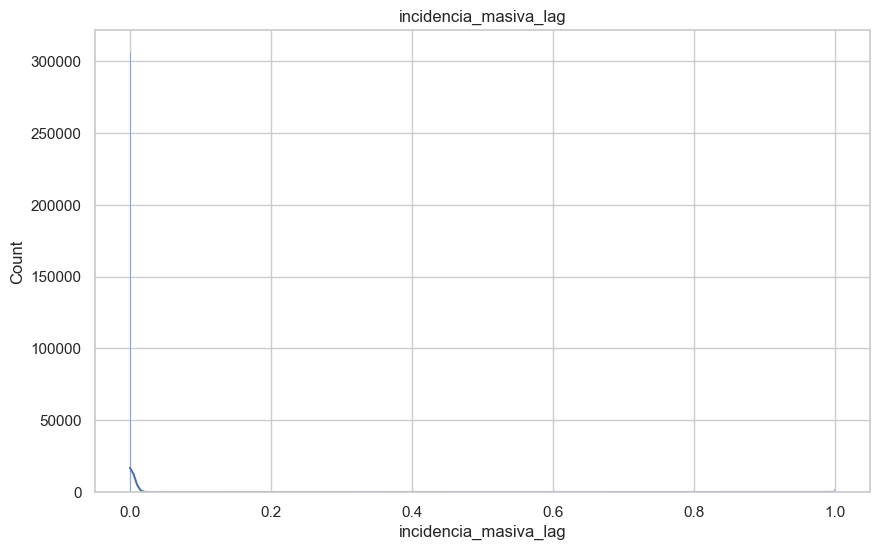

impago_mes


count   308,487.00
mean          0.27
std           0.44
min           0.00
25%           0.00
50%           0.00
75%           1.00
max           1.00
Name: impago_mes, dtype: float64

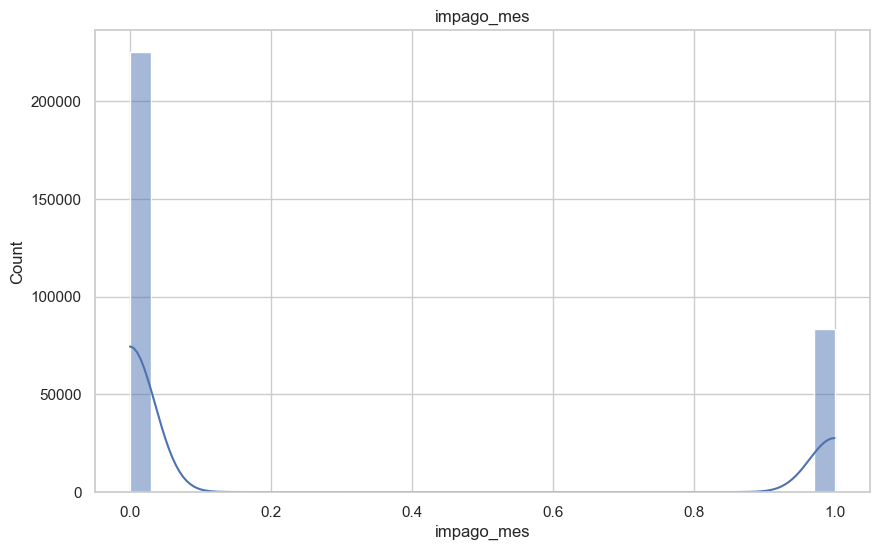

dias_retraso_mes


count   308,487.00
mean          7.07
std          12.77
min           0.00
25%           0.00
50%           0.00
75%          11.00
max          64.00
Name: dias_retraso_mes, dtype: float64

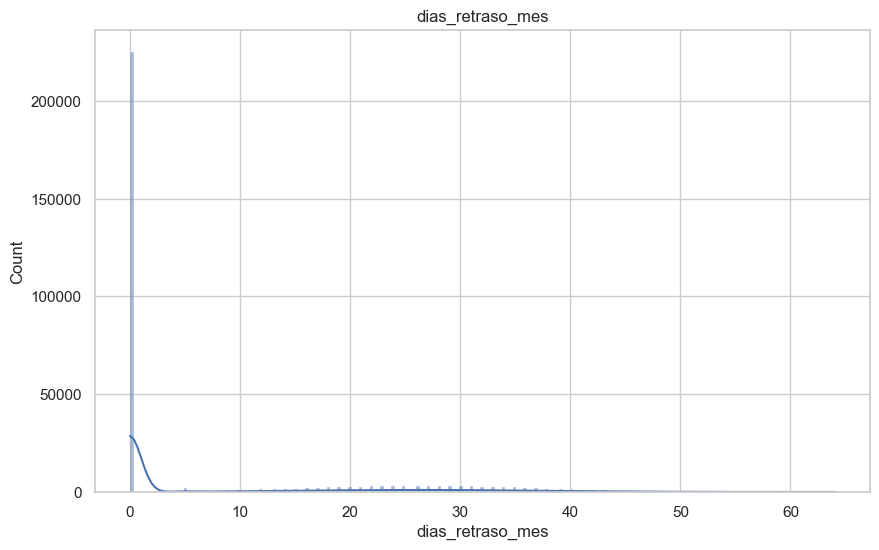

hora


count   303,846.00
mean          0.00
std           0.00
min           0.00
25%           0.00
50%           0.00
75%           0.00
max           0.00
Name: hora, dtype: float64

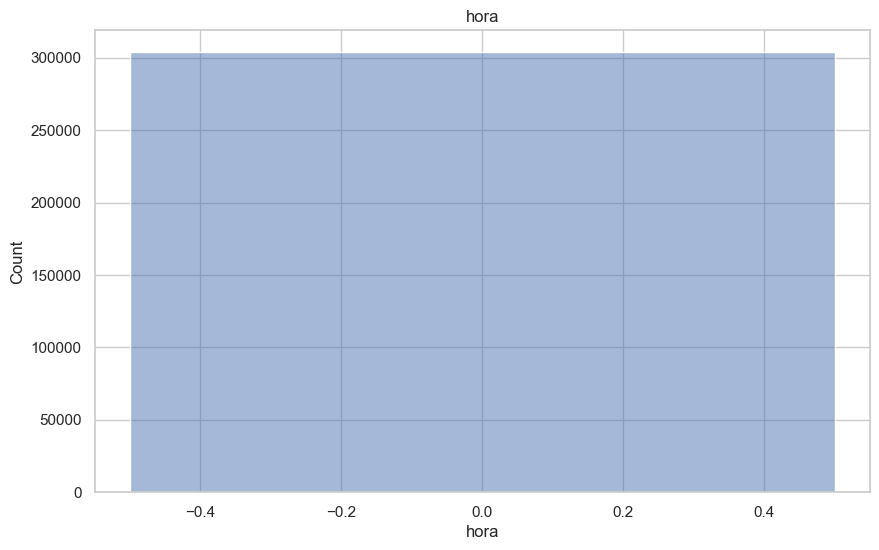

In [42]:
for col in num_cols:
    print(col)
    display(df_analitica[col].describe())

    sns.histplot(df_analitica[col], kde=True)
    plt.title(col)
    plt.show()

interaccion_id


interaccion_id
I716491295118    2
I271008632610    2
I831660710653    2
I666962040807    2
I721437122731    2
I747915945768    2
I705123563177    2
I801443917956    2
I748444381545    2
I389032705098    2
Name: count, dtype: int64

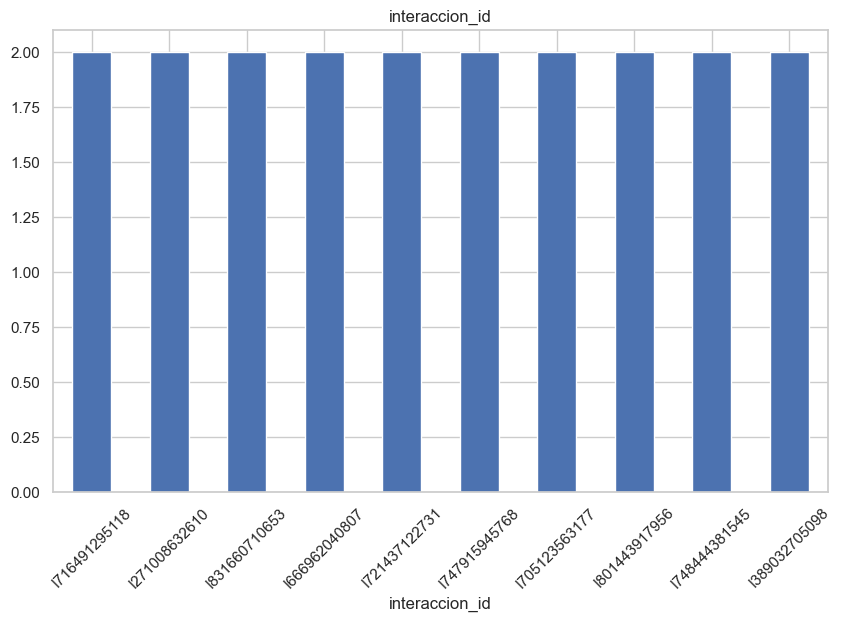

cliente_id


cliente_id
C005384    84
C004160    79
C008164    79
C004938    78
C008291    78
C003079    77
C000351    76
C000786    73
C002323    73
C003705    73
Name: count, dtype: int64

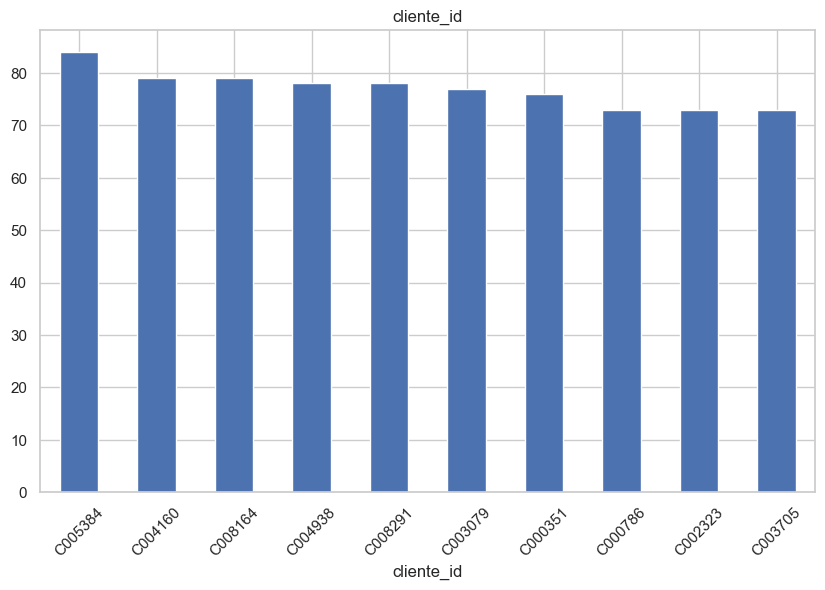

canal


canal
telefono          137187
app_chat          106171
tienda             36251
email              24240
carrier-pigeon      1573
paloma              1556
fax                 1509
Name: count, dtype: int64

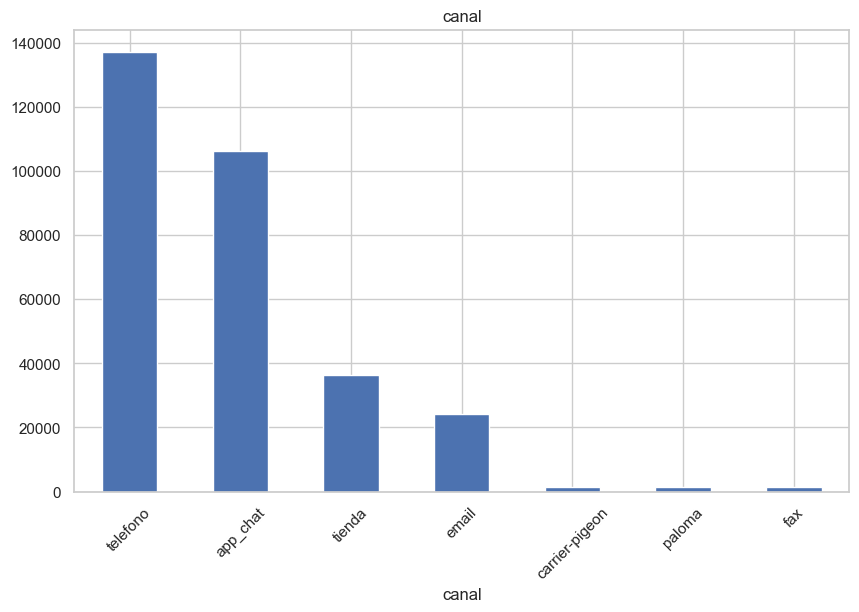

motivo


motivo
Calidad de señal         62963
Consulta general         57831
Impago / pago            52524
Cobertura / velocidad    44372
Facturación              37919
Baja / portabilidad      30804
Cambio de plan           17434
Name: count, dtype: int64

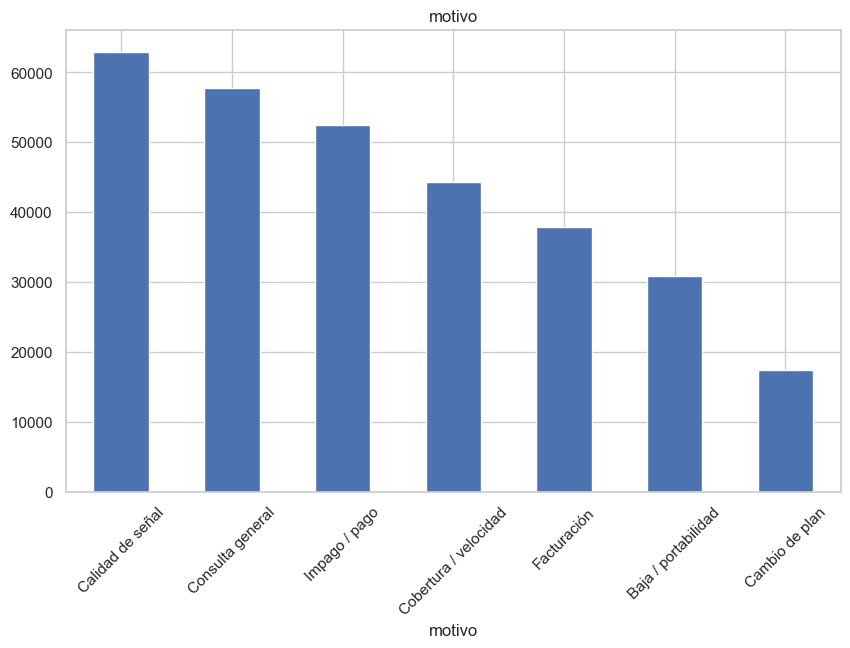

dia_semana


dia_semana
Thursday     43775
Wednesday    43561
Monday       43548
Friday       43486
Sunday       43192
Tuesday      43176
Saturday     43108
Name: count, dtype: int64

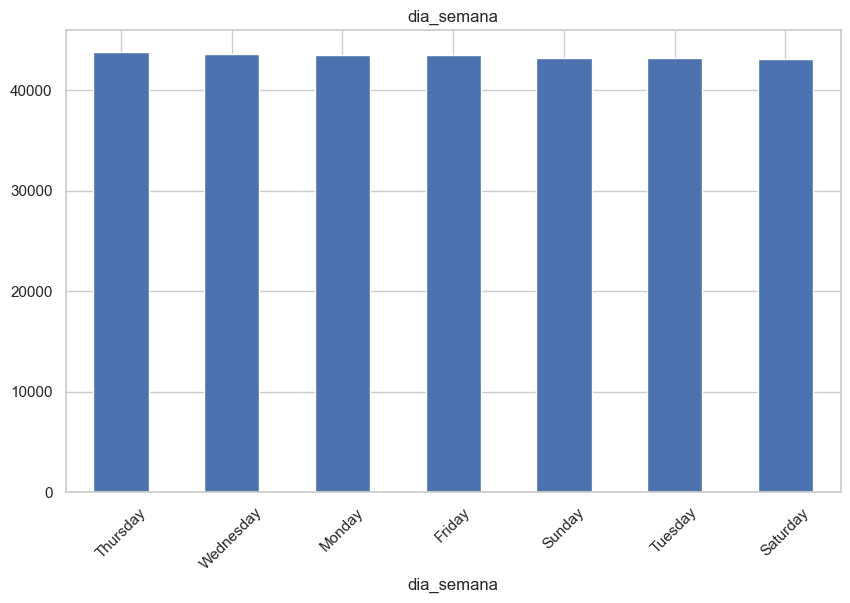

In [44]:
for col in cat_cols:
    print(col)

    vc = df_analitica[col].value_counts().head(10)
    display(vc)

    vc.plot(kind='bar')
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

6.

In [45]:
df_analitica.groupby('incidencia_masiva_lag')['satisfaccion_post'].mean()

incidencia_masiva_lag
0   3.45
1   3.32
Name: satisfaccion_post, dtype: float64

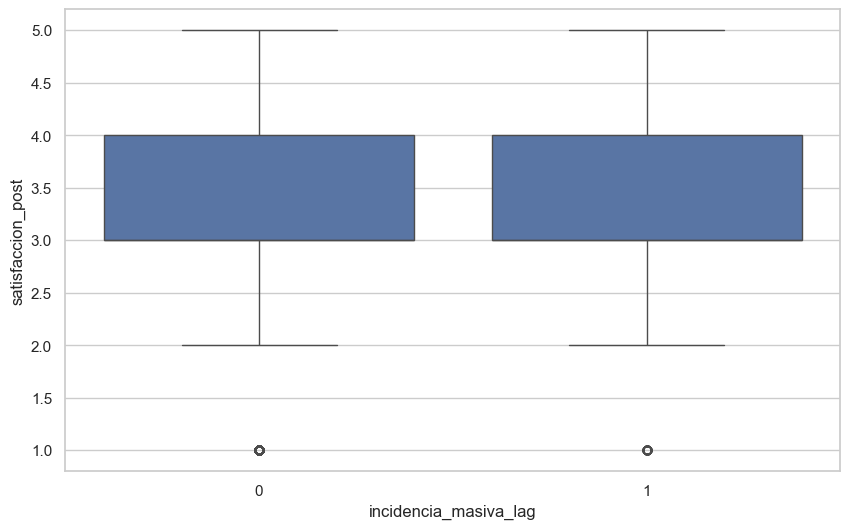

In [46]:
sns.boxplot(x='incidencia_masiva_lag', y='satisfaccion_post', data=df_analitica)
plt.show()

In [47]:
pd.crosstab(df_analitica['motivo'], df_analitica['impago_mes'], normalize='index')

impago_mes,0,1
motivo,,
Baja / portabilidad,0.77,0.23
Calidad de señal,0.85,0.15
Cambio de plan,0.84,0.16
Cobertura / velocidad,0.85,0.15
Consulta general,0.84,0.16
Facturación,0.69,0.31
Impago / pago,0.33,0.67


In [48]:
cramers_v(df_analitica['motivo'], df_analitica['impago_mes'])

np.float64(0.4266679377232734)

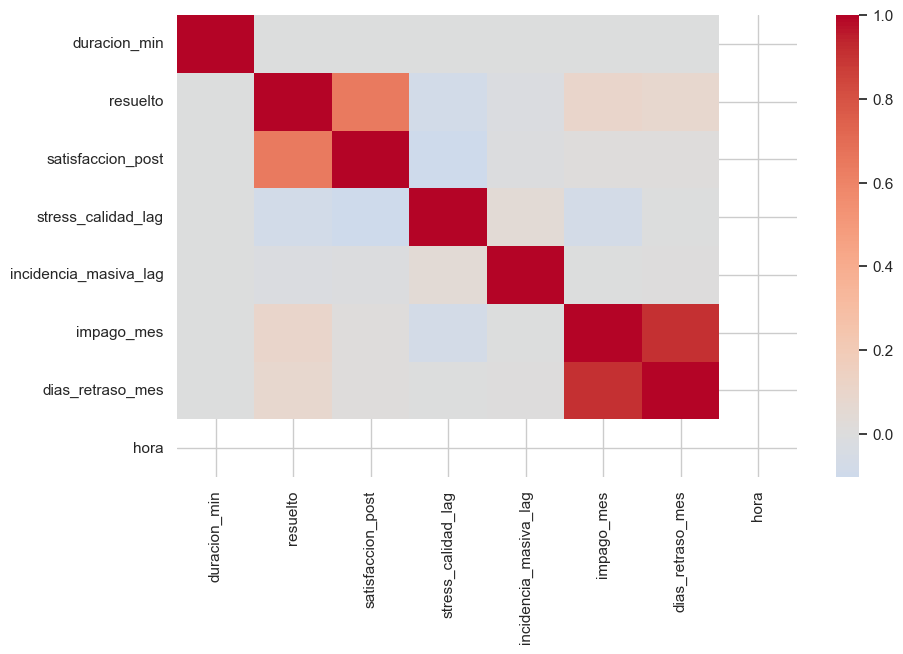

In [49]:
corr = df_analitica[num_cols].corr()

sns.heatmap(corr, cmap='coolwarm', center=0)
plt.show()

In [50]:
for col in num_cols:
    print(col)
    print(iqr_outlier_mask(df_analitica[col]).sum())

duracion_min
3867
resuelto
0
satisfaccion_post
7322
stress_calidad_lag
2867
incidencia_masiva_lag
2076
impago_mes
0
dias_retraso_mes
37283
hora
0


## 8. Conclusiones del EDA

Se observan patrones relevantes en el comportamiento del cliente
Existe relación entre variables operativas y satisfacción
Se detectan posibles problemas de calidad en algunas variables
El dataset es adecuado para análisis posteriores